# 50.007 Machine Learning Course Project
## Detecting human-authored and machine-generated text without deep learning

**Team: TheHomiesML**  
**Primary evaluation metric: Macro F1**  
**Reproducibility seed: 42**

### Problem statement

The goal is binary text classification: label human-authored text as `0` and machine-generated text as `1`. This is difficult because the two classes can discuss the same subjects, writing styles vary substantially across people and generators, and patterns that work on a random validation split may not transfer to previously unseen domains. Macro F1 is therefore appropriate: it computes F1 separately for each class and gives both classes equal importance despite the class imbalance.

### Macro F1 file
The shared Macro F1 calculation is implemented from its definition in `src/evaluation.py`.

---
# 0. Dataset understanding and experimental controls

Before fitting models, we establish the label meaning, class distribution, feature sources and validation protocol. These checks prevent two common mistakes: comparing models on different rows and interpreting accuracy-like behaviour as good Macro F1 performance.

In [3]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Works whether the notebook is opened from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation import calculate_macro_f1
from src.submission import create_submission

DATA_DIR = PROJECT_ROOT / "data"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"      # the graded prediction files
# Working output: tuning tables and plots, not deliverables in their own right.
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for directory in (RESULTS_DIR, SUBMISSIONS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ID_COLUMN = "id"
LABEL_COLUMN = "label"

print("data files present:",
      all((DATA_DIR / name).exists() for name in
          ["train.csv", "test.csv", "train_features.csv", "test_features.csv"]))

data files present: True


## 0.1 Available data

`train.csv` and `test.csv` contain the original text. `train_features.csv` and `test_features.csv` contain the course-provided 5,000-dimensional TF-IDF representation. Tasks 1 and 2 use the provided features so their implementations are assessed under the prescribed conditions. Task 3 first uses the same representation for a controlled model comparison, then introduces explicitly documented feature engineering.

In [4]:
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

print("train:", train_raw.shape, " test:", test_raw.shape)
print("missing values:", train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum())
train_raw.head(3)

train: (20000, 3)  test: (6999, 2)
missing values: 0 0


,id,text,label
0,71ec6000-1f20-4850-a8f7-140bc6ad640d,Instance-level video segmentation requires a s...,1
1,9a494ddf-43c6-4c54-8927-f2343054fef2,Samples of high-redshift galaxies are easy to ...,0
2,bc1dc7e4-d773-4c52-bcc1-ed08ba822f92,"Ashley Sibery, 39, persuaded Sital Sibery to t...",1


## 0.2 Class distribution and metric choice

The training data are moderately imbalanced: 12,504 of 20,000 examples (62.52%) are machine-generated, while 7,496 (37.48%) are human-authored. Predicting only the majority class would appear correct often, but its Macro F1 is only 0.3847 because the human class receives an F1 of zero.

We therefore use **Macro F1**, not accuracy, for every model-selection decision. We also test balanced class weights where appropriate so the minority class contributes equally to the learning objective.

In [5]:
class_distribution = train_raw[LABEL_COLUMN].value_counts().sort_index()
display(pd.DataFrame({
    "Label": ["0 (human-authored)", "1 (machine-generated)"],
    "Count": class_distribution.values,
    "Percentage": (class_distribution.values / len(train_raw) * 100).round(2),
}))

# A model that always guesses the majority class sets the bar to clear
majority = np.ones(len(train_raw), dtype=int)
print("always-predict-1 Macro F1:",
      round(calculate_macro_f1(train_raw[LABEL_COLUMN], majority), 4))

,Label,Count,Percentage
0,0 (human-authored),7496,37.48
1,1 (machine-generated),12504,62.52


always-predict-1 Macro F1: 0.3847


## 0.3 Text-length evidence

This initial analysis asks whether simple document structure differs across labels. It is exploratory rather than a model: any observation here must still be tested through validation before becoming a feature.

In [6]:
import re

lengths = train_raw.assign(
    n_words=train_raw["text"].str.split().str.len(),
    n_chars=train_raw["text"].str.len(),
)
display(lengths.groupby(LABEL_COLUMN)[["n_words", "n_chars"]]
        .agg(["mean", "median", "std"]).round(1))


def sentence_length_std(text):
    """How much sentence length varies inside one document."""
    counts = [len(re.findall(r"\b\w+\b", part))
              for part in re.split(r"[.!?]+", text) if part.strip()]
    return np.std(counts) if len(counts) > 1 else 0.0


sample = train_raw.groupby(LABEL_COLUMN, group_keys=False).sample(2000, random_state=RANDOM_SEED)
display(sample.assign(sentence_std=sample["text"].map(sentence_length_std))
        .groupby(LABEL_COLUMN)["sentence_std"].agg(["mean", "median"]).round(2))

n_words               n_chars                
         mean median    std    mean  median     std
label                                              
0       261.5  176.0  307.2  1529.4  1065.0  1837.8
1       237.6  195.0  186.7  1445.1  1198.0  1120.6

,mean,median
label,,
0,8.86,7.91
1,7.82,6.61


The mean alone hides the useful pattern. Human-authored documents have a higher mean but a lower median length, together with substantially greater standard deviation. This indicates a long right tail: many human documents are short, but some are unusually long. Machine-generated documents are more tightly concentrated around the centre. Sentence length also varies more in the human class (8.86 versus 7.82).

This suggests that **variation and regularity**, not merely document length, may help distinguish the classes. A standard bag-of-words representation cannot directly express sentence-length burstiness, repeated sentence structures or punctuation habits. This observation motivates the stylometric features introduced in Section 3.6; it does not by itself prove that they will improve prediction.

## 0.4 Fixed validation split

All team experiments use the same stratified 80/20 split: 16,000 training rows and 4,000 validation rows. Keeping this split fixed makes model scores directly comparable and prevents a favourable random split from being mistaken for a better algorithm. Assertions verify that IDs and row positions match before any features or labels are selected.

In [7]:
split = pd.read_csv(DATA_DIR / "splits" / "shared_validation_split.csv")
assert len(split) == len(train_raw)
assert split[ID_COLUMN].astype("string").tolist() == train_raw[ID_COLUMN].astype("string").tolist()

is_train = (split["split"] == "train").to_numpy()
print("train rows:", is_train.sum(), " validation rows:", (~is_train).sum())
print("class-1 rate  train:", round(train_raw.loc[is_train, LABEL_COLUMN].mean(), 4),
      " validation:", round(train_raw.loc[~is_train, LABEL_COLUMN].mean(), 4))

train rows: 16000  validation rows: 4000
class-1 rate  train: 0.6252  validation: 0.6252


## 0.5 Supplied TF-IDF features

The provided matrix has 5,000 TF-IDF columns. TF-IDF gives a term a large value when it is frequent in one document but relatively uncommon across the collection. Tasks 1 and 2 use this matrix as required. Sections 3.1-3.5 also use it so differences can be attributed to the model rather than the representation. Only Section 3.6 changes the feature space.

In [8]:
FEATURES = [c for c in pd.read_csv(DATA_DIR / "train_features.csv", nrows=0).columns
            if c not in (ID_COLUMN, LABEL_COLUMN)]
assert len(FEATURES) == 5000, f"expected 5000 features, got {len(FEATURES)}"

dtypes = {c: np.float32 for c in FEATURES}
train_features = pd.read_csv(DATA_DIR / "train_features.csv", dtype=dtypes)
test_features = pd.read_csv(DATA_DIR / "test_features.csv", dtype=dtypes)

X_all = train_features[FEATURES].to_numpy(np.float32)
y_all = train_features[LABEL_COLUMN].to_numpy()
X_test = test_features[FEATURES].to_numpy(np.float32)
test_ids = test_features[ID_COLUMN].copy()

X_train, y_train = X_all[is_train], y_all[is_train]
X_val, y_val = X_all[~is_train], y_all[~is_train]

del train_features
print(X_train.shape, X_val.shape, X_test.shape)

(16000, 5000) (4000, 5000) (6999, 5000)


---
# Task 1 - Logistic Regression from scratch

The required Logistic Regression learner is implemented without a predefined estimator. The five central functions are `sigmoid`, `loss`, `gradients`, `train` and `predict`.

### Plain-language explanation

Logistic Regression draws one linear decision boundary through the feature space. Each TF-IDF feature receives a learned weight. For a document vector $\mathbf{x}$, the model computes

$$z=\mathbf{w}^{\top}\mathbf{x}+b$$

and converts that score to a value between zero and one using

$$\sigma(z)=\frac{1}{1+e^{-z}}.$$

A probability above the selected threshold is assigned to class 1. During training, binary cross-entropy gives a large penalty to confident incorrect predictions. Mini-batch gradient descent repeatedly calculates how each weight contributed to the error and moves the parameters in the direction that reduces loss:

$$L=-\frac{1}{m}\sum_{i=1}^{m}[y_i\log\hat y_i+(1-y_i)\log(1-\hat y_i)].$$

The gradients are $X^{\top}(\hat{\mathbf y}-\mathbf y)/m$ for the weights and the mean prediction error for the bias. Clipping protects the sigmoid and logarithm from numerical overflow.

### 1.1 Implementation

In [9]:
import numpy as np


def sigmoid(z):
    """Squash any real number into the range (0, 1)."""
    z = np.clip(z, -500, 500)          # prevents exp() overflow
    return 1.0 / (1.0 + np.exp(-z))


def loss(y, y_hat, sample_weight=None):
    """Log loss (binary cross-entropy) between true and predicted labels."""
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)   # prevents log(0)
    per_row = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    if sample_weight is None:
        return np.mean(per_row)
    return np.sum(sample_weight * per_row) / np.sum(sample_weight)


def gradients(X, y, y_hat, sample_weight=None):
    """Partial derivatives of the log loss w.r.t. the weights and the bias."""
    m = X.shape[0]
    error = y_hat - y
    if sample_weight is not None:
        error = error * sample_weight
    return (X.T @ error) / m, np.sum(error) / m


def train(X, y, bs, epochs, lr, l2=0.0, class_weight=None, shuffle=True,
          seed=42, verbose=False):
    """Mini-batch gradient descent for logistic regression.

    bs, epochs and lr keep the positional order required by the task brief.
    The keyword arguments are the additions we tuned:

        l2           weight of the L2 penalty (0.0 reproduces the first version)
        class_weight "balanced" to reweight the classes to equal total mass
        shuffle      reshuffle the row order before every epoch
    """
    # A pandas Series would index by label rather than position below, so the
    # batch lookups have to be done on a plain array
    y = np.asarray(y, dtype=np.float64)
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    losses = []
    n_batches = (m - 1) // bs + 1
    rng = np.random.default_rng(seed)

    if class_weight == "balanced":
        classes, counts = np.unique(y, return_counts=True)
        weight_map = {c: m / (len(classes) * count) for c, count in zip(classes, counts)}
        sample_weight = np.array([weight_map[label] for label in y])
    else:
        sample_weight = None

    for epoch in range(epochs):
        # Reshuffling each epoch stops the model from seeing the same fixed
        # batches in the same order every time
        order = rng.permutation(m) if shuffle else np.arange(m)

        for i in range(n_batches):
            batch_idx = order[i * bs:(i + 1) * bs]
            xb = X[batch_idx]
            yb = y[batch_idx]
            swb = None if sample_weight is None else sample_weight[batch_idx]

            y_hat = sigmoid(xb @ w + b)
            dw, db = gradients(xb, yb, y_hat, swb)
            dw = dw + l2 * w                     # L2 penalty, bias left out
            w -= lr * dw
            b -= lr * db

        losses.append(loss(y, sigmoid(X @ w + b), sample_weight))
        if verbose and (epoch + 1) % 50 == 0:
            print(f"  epoch {epoch+1:4d}  loss {losses[-1]:.6f}")

    return w, b, losses


def predict(X, w, b, threshold=0.5):
    """Label each row 1 when its predicted probability clears the threshold."""
    return (sigmoid(X @ w + b) >= threshold).astype(int)


def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

## 1.2 Training sanity check

A correct implementation should do more than run: its loss should decrease and its validation score should exceed the majority baseline. The first fit is therefore a diagnostic. The steadily falling loss confirms that the gradient direction and parameter updates are coherent.

  epoch   50  loss 0.448315
  epoch  100  loss 0.403218
  epoch  150  loss 0.377922
  epoch  200  loss 0.360634
  epoch  250  loss 0.347668
  epoch  300  loss 0.337394
loss: 0.6407 -> 0.3374
validation Macro F1: 0.7352


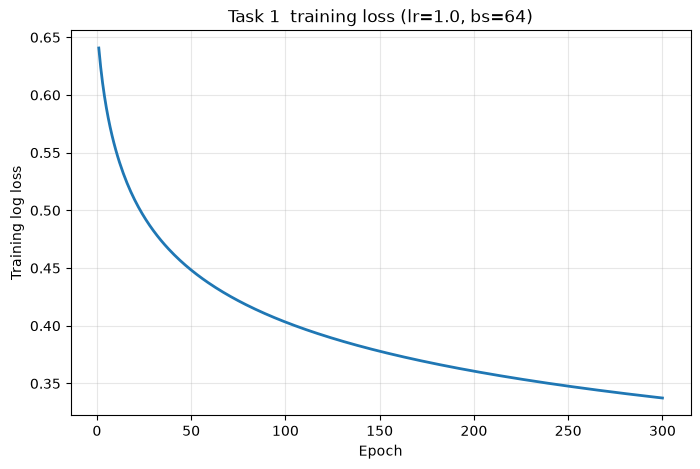

In [10]:
w, b, losses = train(X_train, y_train.astype(np.float64),
                     bs=64, epochs=300, lr=1.0, shuffle=False, verbose=True)

print("loss:", round(losses[0], 4), "->", round(losses[-1], 4))
print("validation Macro F1:", round(calculate_macro_f1(y_val, predict(X_val, w, b)), 4))
assert losses[-1] < losses[0], "loss should decrease"

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses) + 1), losses, linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Training log loss")
plt.title("Task 1  training loss (lr=1.0, bs=64)")
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / "logreg_training_loss.png", dpi=150)
plt.show()

## 1.3 Hyperparameter tuning and interpretation

We vary a small set of meaningful controls rather than searching blindly:

1. **Learning rate** controls the size of each gradient step. Too small converges slowly; too large can overshoot a good solution.
2. **Epochs** control how many full passes are made through the training set. More epochs help until additional fitting begins to model noise.
3. **Batch size** trades noisier, more frequent updates against smoother, less frequent updates.
4. **Shuffling** changes mini-batch composition each epoch and may prevent order-specific updates.
5. **L2 regularisation** shrinks large coefficients, reducing reliance on individual TF-IDF features.
6. **Balanced class weighting** increases the influence of the smaller human class.
7. **Decision threshold** changes the precision-recall trade-off without retraining. Because Macro F1 weights both classes equally, 0.5 need not be optimal on an imbalanced dataset.

All choices are made using only the fixed validation split. Test labels are never used.

In [11]:
def best_threshold(y_true, scores, metric, low=0.05, high=0.95, steps=91):
    """Pick the cut-off on `scores` with the best metric value.

    The grid is deliberately coarse: a finer one just fits the noise in a
    single 4000-row validation split.
    """
    candidates = np.quantile(scores, np.linspace(low, high, steps))
    values = [metric(y_true, (scores >= t).astype(int)) for t in candidates]
    best = int(np.argmax(values))
    return float(candidates[best]), float(values[best])

In [12]:
results = []


def run_config(label, **kwargs):
    settings = {"bs": 64, "epochs": 300, "lr": 1.0}
    settings.update(kwargs)

    t0 = time.time()
    w, b, hist = train(X_train, y_train.astype(np.float64), **settings)
    probabilities = predict_proba(X_val, w, b)

    default_f1 = calculate_macro_f1(y_val, (probabilities >= 0.5).astype(int))
    threshold, tuned_f1 = best_threshold(y_val, probabilities, calculate_macro_f1)

    results.append({
        "config": label,
        "learning_rate": settings["lr"], "epochs": settings["epochs"],
        "batch_size": settings["bs"], "l2": settings.get("l2", 0.0),
        "class_weight": str(settings.get("class_weight")),
        "shuffle": settings.get("shuffle", True),
        "final_train_loss": hist[-1],
        "val_macro_f1": default_f1,
        "best_threshold": threshold,
        "val_macro_f1_tuned": tuned_f1,
        "runtime_s": round(time.time() - t0, 1),
    })
    print(f"{label:<40} F1={default_f1:.4f}  tuned={tuned_f1:.4f} (t={threshold:.3f})")


run_config("baseline (no shuffle, no L2)", shuffle=False)
run_config("shuffle")
for l2 in [1e-5, 1e-4, 1e-3]:
    run_config(f"shuffle + l2={l2}", l2=l2)
run_config("shuffle + l2=1e-05 + balanced", l2=1e-5, class_weight="balanced")
for lr in [0.5, 2.0]:
    run_config(f"shuffle + l2=1e-05 + lr={lr}", l2=1e-5, lr=lr)
run_config("shuffle + l2=1e-05 + epochs=500", l2=1e-5, epochs=500)

logreg_results = (pd.DataFrame(results)
                  .sort_values("val_macro_f1_tuned", ascending=False)
                  .reset_index(drop=True))
logreg_results.to_csv(RESULTS_DIR / "logreg_tuning_results.csv", index=False)
logreg_results

baseline (no shuffle, no L2)             F1=0.7352  tuned=0.7376 (t=0.586)
shuffle                                  F1=0.7254  tuned=0.7386 (t=0.631)
shuffle + l2=1e-05                       F1=0.7225  tuned=0.7394 (t=0.587)
shuffle + l2=0.0001                      F1=0.6444  tuned=0.7389 (t=0.614)
shuffle + l2=0.001                       F1=0.4005  tuned=0.6943 (t=0.650)
shuffle + l2=1e-05 + balanced            F1=0.7353  tuned=0.7410 (t=0.476)
shuffle + l2=1e-05 + lr=0.5              F1=0.7227  tuned=0.7440 (t=0.627)
shuffle + l2=1e-05 + lr=2.0              F1=0.7167  tuned=0.7393 (t=0.608)
shuffle + l2=1e-05 + epochs=500          F1=0.7374  tuned=0.7391 (t=0.530)


,config,learning_rate,epochs,batch_size,l2,class_weight,shuffle,final_train_loss,val_macro_f1,best_threshold,val_macro_f1_tuned,runtime_s
0,shuffle + l2=1e-05 + lr=0.5,0.5,300,64,0.00001,None,True,0.394779,0.722655,0.627466,0.743964,18.9
1,shuffle + l2=1e-05 + balanced,1.0,300,64,0.00001,balanced,True,0.379213,0.735279,0.475968,0.741029,19.0
2,shuffle + l2=1e-05,1.0,300,64,0.00001,None,True,0.368193,0.722498,0.586793,0.739416,18.9
3,shuffle + l2=1e-05 + lr=2.0,2.0,300,64,0.00001,None,True,0.354395,0.716698,0.607588,0.739262,19.0
4,shuffle + l2=1e-05 + epochs=500,1.0,500,64,0.00001,None,True,0.356059,0.737351,0.530154,0.739055,32.2
5,shuffle + l2=0.0001,1.0,300,64,0.00010,None,True,0.486014,0.644443,0.613959,0.738878,18.9
6,shuffle,1.0,300,64,0.00000,None,True,0.338709,0.725436,0.631437,0.738641,18.9
7,"baseline (no shuffle, no L2)",1.0,300,64,0.00000,None,False,0.337394,0.735212,0.585621,0.737592,17.3
8,shuffle + l2=0.001,1.0,300,64,0.00100,None,True,0.608250,0.400481,0.650381,0.694334,18.9


### Interpretation of the Task 1 tuning results

The untuned implementation reaches 0.7352 validation Macro F1. The best recorded tuned configuration reaches approximately 0.7440. A light L2 penalty is useful, whereas `l2=0.001` shrinks the model too strongly and reduces performance sharply. Shuffling alone does not reliably help. Learning rate 0.5 with light L2 gives the best result in this small search, although the top configurations differ by only a few thousandths.

Threshold tuning contributes more consistently than most optimiser changes because it directly corrects the class-specific precision-recall balance. However, the narrow gap among leading settings is comparable to uncertainty from a 4,000-row validation set, so we avoid claiming that a tiny decimal difference represents a universal improvement.

**Reported Task 1 result:** the recorded Kaggle public Macro F1 for the individual Logistic Regression submission is **0.68563**.

In [13]:
best = logreg_results.iloc[0]
BEST_LR = float(best["learning_rate"])
BEST_EPOCHS = int(best["epochs"])
BEST_BS = int(best["batch_size"])
BEST_L2 = float(best["l2"])
BEST_CLASS_WEIGHT = None if best["class_weight"] == "None" else best["class_weight"]
BEST_SHUFFLE = bool(best["shuffle"])
BEST_THRESHOLD = float(best["best_threshold"])

print(f"selected: lr={BEST_LR}, epochs={BEST_EPOCHS}, bs={BEST_BS}, l2={BEST_L2}, "
      f"class_weight={BEST_CLASS_WEIGHT}, threshold={BEST_THRESHOLD:.4f}")
print("validation Macro F1:", round(float(best["val_macro_f1_tuned"]), 4))

selected: lr=0.5, epochs=300, bs=64, l2=1e-05, class_weight=None, threshold=0.6275
validation Macro F1: 0.744


## 1.4 Final fitting and prediction

After selecting hyperparameters on validation, the model is trained again on all 20,000 labelled examples. This gives the final learner access to every available training row without using test labels. The generated file is checked for column names, ID order, length, missing values and binary labels before submission.

In [14]:
final_w, final_b, _ = train(X_all, y_all.astype(np.float64),
                            bs=BEST_BS, epochs=BEST_EPOCHS, lr=BEST_LR,
                            l2=BEST_L2, class_weight=BEST_CLASS_WEIGHT,
                            shuffle=BEST_SHUFFLE, verbose=True)

logreg_test_preds = predict(X_test, final_w, final_b, threshold=BEST_THRESHOLD)

logreg_submission = create_submission(
    test_ids=test_ids,
    predictions=logreg_test_preds,
    output_path=SUBMISSIONS_DIR / "LogReg_Prediction.csv",
    id_column=ID_COLUMN,
    label_column=LABEL_COLUMN,
)
print("class-1 rate:", round(float(logreg_test_preds.mean()), 4))
logreg_submission.head()

  epoch   50  loss 0.488652
  epoch  100  loss 0.447961
  epoch  150  loss 0.428985
  epoch  200  loss 0.413464
  epoch  250  loss 0.404621
  epoch  300  loss 0.397393
class-1 rate: 0.6755


,id,label
0,59218,1
1,37110,1
2,23200,0
3,e3357348-166e-4847-a06d-158b7cd83aa5,1
4,61615,0


In [15]:
# Format check: right columns, right length, IDs in their original order
saved = pd.read_csv(SUBMISSIONS_DIR / "LogReg_Prediction.csv", dtype={ID_COLUMN: "string"})
assert saved.columns.tolist() == [ID_COLUMN, LABEL_COLUMN]
assert len(saved) == len(test_ids)
assert saved[ID_COLUMN].tolist() == test_ids.astype("string").tolist()
assert saved[LABEL_COLUMN].isnull().sum() == 0
assert set(saved[LABEL_COLUMN].unique()).issubset({0, 1})
print("LogReg_Prediction.csv verified  ready to upload")

LogReg_Prediction.csv verified  ready to upload


---
# Task 2 - PCA followed by KNN

Task 2 uses scikit-learn implementations of PCA and KNN, with `n_neighbors=2` fixed by the brief.

### How the method works

PCA rotates the original 5,000-dimensional TF-IDF space onto new orthogonal axes called principal components. The first component captures the largest remaining variance, the second captures the next largest, and so on. Retaining fewer components compresses documents and removes lower-variance directions.

KNN does not learn a global equation. For each validation or test document, it finds the two closest training examples in the PCA space and assigns a label from those neighbours. This makes distance quality crucial: if dimensions are noisy or all points become similarly far apart, the nearest neighbours may not be meaningful.

In [16]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

N_NEIGHBOURS = 2                       # fixed by the task brief
COMPONENT_SETTINGS = [2000, 1000, 500, 100]


def evaluate_pca(n_components):
    """Fit PCA and KNN on the training split and score on the validation split."""
    start = time.time()

    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    knn = KNeighborsClassifier(n_neighbors=N_NEIGHBOURS)
    knn.fit(X_train_pca, y_train)
    predictions = knn.predict(X_val_pca)

    return {
        "components": n_components,
        "val_macro_f1": calculate_macro_f1(y_val, predictions),
        "explained_variance": float(pca.explained_variance_ratio_.sum()),
        "pred_class1_rate": float(predictions.mean()),
        "runtime_s": round(time.time() - start, 1),
    }


pca_results = pd.DataFrame([evaluate_pca(n) for n in COMPONENT_SETTINGS])
pca_results.to_csv(RESULTS_DIR / "pca_knn_results.csv", index=False)
pca_results

,components,val_macro_f1,explained_variance,pred_class1_rate,runtime_s
0,2000,0.400742,0.781895,0.08300,5.4
1,1000,0.475290,0.567997,0.15125,2.3
2,500,0.560290,0.389543,0.27125,1.1
3,100,0.655640,0.158952,0.44825,0.4


## 2.1 Dimensionality analysis

The result initially appears counter-intuitive: retaining more variance produces worse Macro F1. With 2,000 components, PCA preserves about 78% of the variance but KNN achieves only 0.4007 validation Macro F1. With 100 components, only about 16% of variance remains, yet Macro F1 rises to 0.6556.

This happens for two reasons:

1. **Variance is not the same as class information.** PCA is unsupervised and preserves directions with high overall variation, even if they do not help separate human and machine-generated text. Low-variance directions may also add noise to distance calculations.
2. **Distance concentration.** In high-dimensional spaces, the distances from a point to its nearest and farthest neighbours become more similar. KNN then loses the contrast needed to identify a meaningful local neighbourhood.

Reducing to 100 components acts as denoising: it discards much of the original variance but creates a space in which proximity is more useful for classification.

In [17]:
tie_rows = []
for n_components in COMPONENT_SETTINGS:
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    knn = KNeighborsClassifier(n_neighbors=N_NEIGHBOURS).fit(X_train_pca, y_train)
    _, neighbour_idx = knn.kneighbors(X_val_pca)
    neighbour_labels = y_train[neighbour_idx]

    is_tie = neighbour_labels[:, 0] != neighbour_labels[:, 1]
    tie_rows.append({
        "components": n_components,
        "tie_rate": float(is_tie.mean()),
        "true_class1_rate_among_ties": float(y_val[is_tie].mean()),
        "val_macro_f1_k2": calculate_macro_f1(y_val, knn.predict(X_val_pca)),
        # the nearest neighbour on its own, i.e. the same model without the tie rule
        "val_macro_f1_k1": calculate_macro_f1(y_val, neighbour_labels[:, 0]),
    })

tie_analysis = pd.DataFrame(tie_rows)
tie_analysis.to_csv(RESULTS_DIR / "pca_knn_tie_analysis.csv", index=False)
tie_analysis

,components,tie_rate,true_class1_rate_among_ties,val_macro_f1_k2,val_macro_f1_k1
0,2000,0.23100,0.738095,0.400742,0.494368
1,1000,0.28825,0.666088,0.475290,0.556752
2,500,0.36100,0.603186,0.560290,0.614481
3,100,0.35375,0.547703,0.655640,0.667906


## 2.2 Effect of fixing `k=2`

An even neighbour count creates ties. When the two nearest neighbours disagree, scikit-learn resolves the tie in favour of the lower class index, class 0. At 2,000 components, approximately 23% of validation predictions are ties, and around 74% of those tied rows are actually class 1. This explains why the model predicts class 1 for only about 8% of rows despite a true rate near 63%.

The diagnostic `k=1` column removes ties and recovers roughly 0.09 Macro F1 at 2,000 components. We do **not** use `k=1` for the official submission because the task fixes `k=2`

**Reported Task 2 result:** among the recorded Kaggle submissions, PCA(100) + KNN achieved **0.67793** public Macro F1 and was the strongest PCA setting.

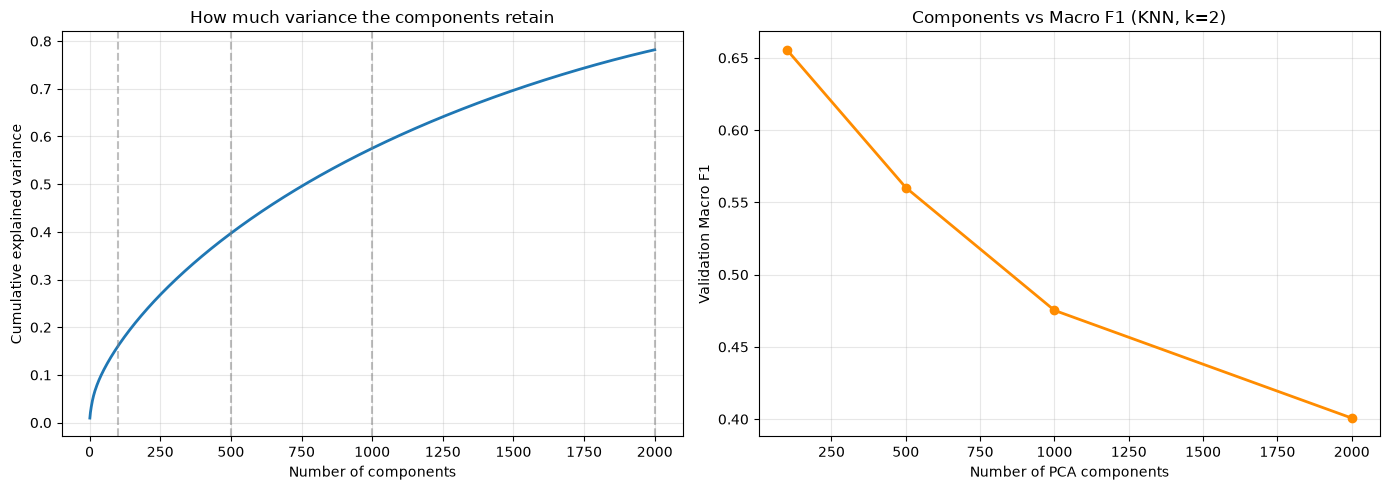

,components,share_of_original_features,cumulative_explained_variance
0,100,0.02,0.160022
1,500,0.10,0.397017
2,1000,0.20,0.575253
3,2000,0.40,0.781896


In [18]:
full_pca = PCA(n_components=max(COMPONENT_SETTINGS), random_state=RANDOM_SEED)
full_pca.fit(X_train)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)

variance_analysis = pd.DataFrame([{
    "components": n,
    "share_of_original_features": n / len(FEATURES),
    "cumulative_explained_variance": float(cumulative_variance[n - 1]),
} for n in sorted(COMPONENT_SETTINGS)])
variance_analysis.to_csv(RESULTS_DIR / "pca_variance_analysis.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
for n in COMPONENT_SETTINGS:
    axes[0].axvline(n, color="grey", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Number of components"); axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("How much variance the components retain"); axes[0].grid(alpha=0.3)

axes[1].plot(pca_results["components"], pca_results["val_macro_f1"],
             marker="o", linewidth=2, color="darkorange")
axes[1].set_xlabel("Number of PCA components"); axes[1].set_ylabel("Validation Macro F1")
axes[1].set_title(f"Components vs Macro F1 (KNN, k={N_NEIGHBOURS})"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_knn_analysis.png", dpi=150)
plt.show()
display(variance_analysis)

## 2.3 Four required Kaggle submissions

Separate predictions are produced for 2,000, 1,000, 500 and 100 components. Each PCA transformation and KNN model is refitted on all labelled rows after the component comparison is complete. The four files allow the leaderboard results to be reported alongside the local dimensionality trend.

In [19]:
for n_components in COMPONENT_SETTINGS:
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_all_pca = pca.fit_transform(X_all)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=N_NEIGHBOURS).fit(X_all_pca, y_all)
    test_preds = knn.predict(X_test_pca)

    create_submission(
        test_ids=test_ids,
        predictions=test_preds,
        output_path=SUBMISSIONS_DIR / f"PCA{n_components}_KNN_Prediction.csv",
        id_column=ID_COLUMN,
        label_column=LABEL_COLUMN,
    )
    print(f"PCA{n_components}_KNN_Prediction.csv saved; "
          f"class-1 rate={test_preds.mean():.4f}")

PCA2000_KNN_Prediction.csv saved; class-1 rate=0.0590
PCA1000_KNN_Prediction.csv saved; class-1 rate=0.1767
PCA500_KNN_Prediction.csv saved; class-1 rate=0.3686
PCA100_KNN_Prediction.csv saved; class-1 rate=0.5449


---
# Task 3 - Classical models and feature engineering

Task 3 explores several classical model families. The experimental roadmap is intentionally staged:

1. Hold the supplied 5,000 TF-IDF features constant and compare Multinomial NB, Complement NB, three SGD losses, Extra Trees and a soft-vote ensemble.
2. Keep the strongest from-scratch linear trainer but improve its input using word n-grams, character n-grams and stylometry.
3. Compare losses and stylometry weights under the same fixed split.
4. Diagnose the gap between random validation and Kaggle with topic-cluster holdout validation.
5. Refit the selected model on all labelled examples.

The standalone Naive Bayes and SGD learners are written with NumPy. Extra Trees uses a library under the permitted ensemble exception.

## 3.1 Multinomial Naive Bayes from scratch

### Intuition

Multinomial Naive Bayes treats each feature as evidence for a class. For every class, it estimates how much total TF-IDF mass belongs to each feature and combines that evidence with the class prior. Products of many small probabilities would underflow numerically, so the implementation adds log-probabilities instead.

The conditional-independence assumption is intentionally simple: it behaves as though features are independent once the class is known. Word features are clearly related, but this approximation makes the model fast and provides a useful probabilistic baseline.

### Hyperparameter

`alpha` is additive smoothing. It prevents an unseen feature from making an entire class probability zero. Too much smoothing makes class-specific feature patterns look alike; too little may make estimates unstable.

In [20]:
def nb_fit(X, y, alpha=1.0):
    """Estimate the class priors and the smoothed per-feature likelihoods."""
    classes = np.unique(y)
    class_log_prior = np.zeros(len(classes))
    feature_log_prob = np.zeros((len(classes), X.shape[1]))

    for idx, c in enumerate(classes):
        X_c = X[y == c]
        class_log_prior[idx] = np.log(X_c.shape[0] / X.shape[0])

        # alpha is Laplace/Lidstone smoothing, so unseen terms are not zeroed
        feature_mass = np.asarray(X_c.sum(axis=0)).ravel() + alpha
        feature_log_prob[idx] = np.log(feature_mass / feature_mass.sum())

    return classes, class_log_prior, feature_log_prob


def nb_predict_log_proba(X, class_log_prior, feature_log_prob):
    return X @ feature_log_prob.T + class_log_prior


def nb_predict(X, classes, class_log_prior, feature_log_prob):
    log_proba = nb_predict_log_proba(X, class_log_prior, feature_log_prob)
    return classes[np.argmax(log_proba, axis=1)]


def nb_predict_proba(X, class_log_prior, feature_log_prob):
    log_proba = nb_predict_log_proba(X, class_log_prior, feature_log_prob)
    log_proba -= log_proba.max(axis=1, keepdims=True)   # stabilise before exp
    proba = np.exp(log_proba)
    return proba / proba.sum(axis=1, keepdims=True)

In [21]:
nb_grid = []
for alpha in [0.001, 0.01, 0.1, 0.5, 1.0]:
    classes, prior, feature_log_prob = nb_fit(X_train, y_train, alpha=alpha)
    score = calculate_macro_f1(y_val, nb_predict(X_val, classes, prior, feature_log_prob))
    nb_grid.append({"alpha": alpha, "val_macro_f1": score})
    print(f"alpha={alpha:<7} F1={score:.4f}")

nb_grid = pd.DataFrame(nb_grid).sort_values("val_macro_f1", ascending=False)
nb_grid.to_csv(RESULTS_DIR / "task3_nb_alpha.csv", index=False)
nb_grid

alpha=0.001   F1=0.6741
alpha=0.01    F1=0.6736
alpha=0.1     F1=0.6719
alpha=0.5     F1=0.6680
alpha=1.0     F1=0.6605


,alpha,val_macro_f1
0,0.001,0.674114
1,0.010,0.673634
2,0.100,0.671927
3,0.500,0.667952
4,1.000,0.660464


### Multinomial NB result

The best tested value is `alpha=0.001`, producing 0.6741 validation Macro F1. Performance falls steadily as `alpha` increases to 1.0. Because the input contains fractional TF-IDF weights rather than raw word counts, a smoothing mass of 1.0 is large relative to the observed per-feature mass and washes out useful differences between classes.

## 3.2 Complement Naive Bayes from scratch

Complement Naive Bayes changes the question from “How typical is this document of class $c$?” to “How unlike the complement of class $c$ is this document?” For each class, it estimates feature weights from all examples outside that class. This design can be more stable for imbalanced text data because it learns from the often larger complement distribution. Weight normalisation prevents a few large totals from dominating.

Here, `alpha` again controls smoothing. The best result occurs at `alpha=2.0` with 0.6669 validation Macro F1. Unlike Multinomial NB, very small values perform poorly, showing that the two formulations respond differently to sparse TF-IDF mass. Complement NB does not beat Multinomial NB on this dataset, but the comparison clarifies that imbalance-aware design alone cannot compensate for limited features.

In [22]:
def cnb_fit(X, y, alpha=1.0, normalize=True):
    classes = np.unique(y)
    complement_weights = np.zeros((len(classes), X.shape[1]))
    total_feature_mass = np.asarray(X.sum(axis=0)).ravel()

    for idx, c in enumerate(classes):
        class_feature_mass = np.asarray(X[y == c].sum(axis=0)).ravel()
        complement_mass = total_feature_mass - class_feature_mass + alpha

        weights = np.log(complement_mass / complement_mass.sum())
        if normalize:
            # keeps long documents from dominating the score
            weights = weights / np.sum(np.abs(weights))

        complement_weights[idx] = weights

    return classes, complement_weights


def cnb_predict_scores(X, complement_weights):
    return X @ complement_weights.T


def cnb_predict(X, classes, complement_weights):
    # low complement score means the document looks unlike the other class
    return classes[np.argmin(cnb_predict_scores(X, complement_weights), axis=1)]

In [23]:
cnb_grid = []
for alpha in [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]:
    classes_c, weights_c = cnb_fit(X_train, y_train, alpha=alpha)
    score = calculate_macro_f1(y_val, cnb_predict(X_val, classes_c, weights_c))
    cnb_grid.append({"alpha": alpha, "val_macro_f1": score})
    print(f"alpha={alpha:<7} F1={score:.4f}")

cnb_grid = pd.DataFrame(cnb_grid).sort_values("val_macro_f1", ascending=False)
cnb_grid.to_csv(RESULTS_DIR / "task3_cnb_alpha.csv", index=False)
cnb_grid

alpha=0.01    F1=0.6324
alpha=0.1     F1=0.6350
alpha=0.5     F1=0.6502
alpha=1.0     F1=0.6603
alpha=2.0     F1=0.6669
alpha=5.0     F1=0.6545


,alpha,val_macro_f1
4,2.00,0.666886
3,1.00,0.660279
5,5.00,0.654549
2,0.50,0.650241
1,0.10,0.634969
0,0.01,0.632382


## 3.3 Linear classifier trained by SGD from scratch

This experiment keeps the optimiser and features fixed while changing only the loss function:

- **Hinge loss** implements a linear maximum-margin classifier. Correct examples still contribute until they lie beyond a safety margin; confidently correct examples then stop updating the boundary.
- **Modified Huber loss** behaves like a smooth hinge near the decision boundary but becomes quadratic for strongly incorrect examples. It offers stable gradients while retaining margin-based behaviour.
- **Log loss** is the Logistic Regression objective and produces probability-oriented scores.

`alpha` controls L2 regularisation: larger values shrink coefficients more aggressively. `class_weight="balanced"` gives the two labels equal aggregate influence. The learning rate decays across updates, and epoch averaging reduces the variability of stochastic optimisation.

Modified Huber performs best on the supplied features at 0.7446 validation Macro F1. `alpha=1e-4` is slightly better than `1e-5` and `1e-3`, suggesting a moderate amount of shrinkage is appropriate.

In [24]:
def compute_grad_f(f, y, loss_name):
    """Derivative of the chosen loss w.r.t. the decision value f."""
    if loss_name == "log_loss":
        return sigmoid(f) - y

    y_signed = 2 * y - 1                 # map {0,1} labels to {-1,+1}
    margin = y_signed * f
    if loss_name == "hinge":
        grad_margin = np.where(margin < 1, -1.0, 0.0)
    elif loss_name == "modified_huber":
        grad_margin = np.where(
            margin <= -1, -4.0,
            np.where(margin >= 1, 0.0, -2.0 * (1 - margin))
        )
    else:
        raise ValueError(f"unsupported loss: {loss_name}")
    return grad_margin * y_signed


def reg_gradient(w, penalty, alpha, l1_ratio=0.15):
    if penalty == "l2":
        return alpha * w
    if penalty == "l1":
        return alpha * np.sign(w)
    if penalty == "elasticnet":
        return alpha * (l1_ratio * np.sign(w) + (1 - l1_ratio) * w)
    raise ValueError(f"unsupported penalty: {penalty}")


def hinge_loss_value(f, y):
    margin = (2 * y - 1) * f
    return np.mean(np.maximum(0, 1 - margin))


def sgd_fit(X, y, loss="hinge", penalty="l2", alpha=0.0001, l1_ratio=0.15,
            lr=0.5, epochs=100, bs=256, class_weight=None, random_state=42,
            X_val=None, y_val=None, eval_fn=None):
    """Mini-batch SGD for a linear classifier.

    Passing X_val/y_val together with eval_fn records the validation score
    after every epoch, which is what the convergence plot uses.
    """
    rng = np.random.default_rng(random_state)
    # A pandas Series would index by label rather than position below, so the
    # batch lookups have to be done on a plain array
    y = np.asarray(y)
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    if class_weight == "balanced":
        classes, counts = np.unique(y, return_counts=True)
        weight_map = {c: m / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
        sample_weight = np.array([weight_map[label] for label in y])
    else:
        sample_weight = np.ones(m)

    n_batches = (m - 1) // bs + 1
    losses = []
    val_history = []

    for epoch in range(epochs):
        order = rng.permutation(m)
        for i in range(n_batches):
            batch_idx = order[i * bs:(i + 1) * bs]
            Xb = X[batch_idx]
            yb = y[batch_idx]
            swb = sample_weight[batch_idx]

            f = np.asarray(Xb @ w).ravel() + b
            grad_f = compute_grad_f(f, yb, loss) * swb

            dw = (np.asarray(Xb.T @ grad_f).ravel() / len(batch_idx)
                  + reg_gradient(w, penalty, alpha, l1_ratio))
            db = grad_f.mean()

            w -= lr * dw
            b -= lr * db

        f_full = np.asarray(X @ w).ravel() + b
        if loss == "hinge":
            losses.append(hinge_loss_value(f_full, y))
        elif loss == "log_loss":
            p = np.clip(sigmoid(f_full), 1e-15, 1 - 1e-15)
            losses.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
        else:
            losses.append(np.mean(np.abs(compute_grad_f(f_full, y, loss))))

        if X_val is not None and y_val is not None and eval_fn is not None:
            val_history.append(eval_fn(y_val, sgd_predict(X_val, w, b)))

    return w, b, losses, val_history


def sgd_decision_function(X, w, b):
    return np.asarray(X @ w).ravel() + b


def sgd_predict(X, w, b, threshold=0.0):
    return (sgd_decision_function(X, w, b) >= threshold).astype(int)

In [25]:
sgd_grid = []
for loss_name in ["hinge", "modified_huber", "log_loss"]:
    t0 = time.time()
    w_s, b_s, _, _ = sgd_fit(X_train, y_train, loss=loss_name, penalty="l2",
                             alpha=1e-4, class_weight="balanced", lr=0.5, epochs=100)
    score = calculate_macro_f1(y_val, sgd_predict(X_val, w_s, b_s))
    sgd_grid.append({"setting": f"loss={loss_name}", "val_macro_f1": score,
                     "fit_seconds": round(time.time() - t0, 1)})
    print(f"loss={loss_name:<16} F1={score:.4f}")

BEST_SGD_LOSS = max(sgd_grid, key=lambda r: r["val_macro_f1"])["setting"].split("=")[1]

for alpha in [1e-5, 1e-4, 1e-3]:
    t0 = time.time()
    w_s, b_s, _, _ = sgd_fit(X_train, y_train, loss=BEST_SGD_LOSS, penalty="l2",
                             alpha=alpha, class_weight="balanced", lr=0.5, epochs=100)
    score = calculate_macro_f1(y_val, sgd_predict(X_val, w_s, b_s))
    sgd_grid.append({"setting": f"{BEST_SGD_LOSS}, alpha={alpha}", "val_macro_f1": score,
                     "fit_seconds": round(time.time() - t0, 1)})
    print(f"alpha={alpha:<8} F1={score:.4f}")

sgd_grid = pd.DataFrame(sgd_grid)
sgd_grid.to_csv(RESULTS_DIR / "task3_sgd_grid.csv", index=False)
sgd_grid

loss=hinge            F1=0.6995
loss=modified_huber   F1=0.7446
loss=log_loss         F1=0.6963
alpha=1e-05    F1=0.7417
alpha=0.0001   F1=0.7446
alpha=0.001    F1=0.7395


,setting,val_macro_f1,fit_seconds
0,loss=hinge,0.699526,7.2
1,loss=modified_huber,0.744562,7.3
2,loss=log_loss,0.696271,7.2
3,"modified_huber, alpha=1e-05",0.741703,7.1
4,"modified_huber, alpha=0.0001",0.744562,7.1
5,"modified_huber, alpha=0.001",0.739518,7.0


### Convergence and overfitting check

The learning curves verify both optimisation and generalisation. Training loss continues to improve, but validation Macro F1 eventually peaks and declines. This is evidence that additional epochs can overfit even when the training objective is still decreasing. Consequently, epochs are treated as a hyperparameter rather than assuming that longer training is always better.

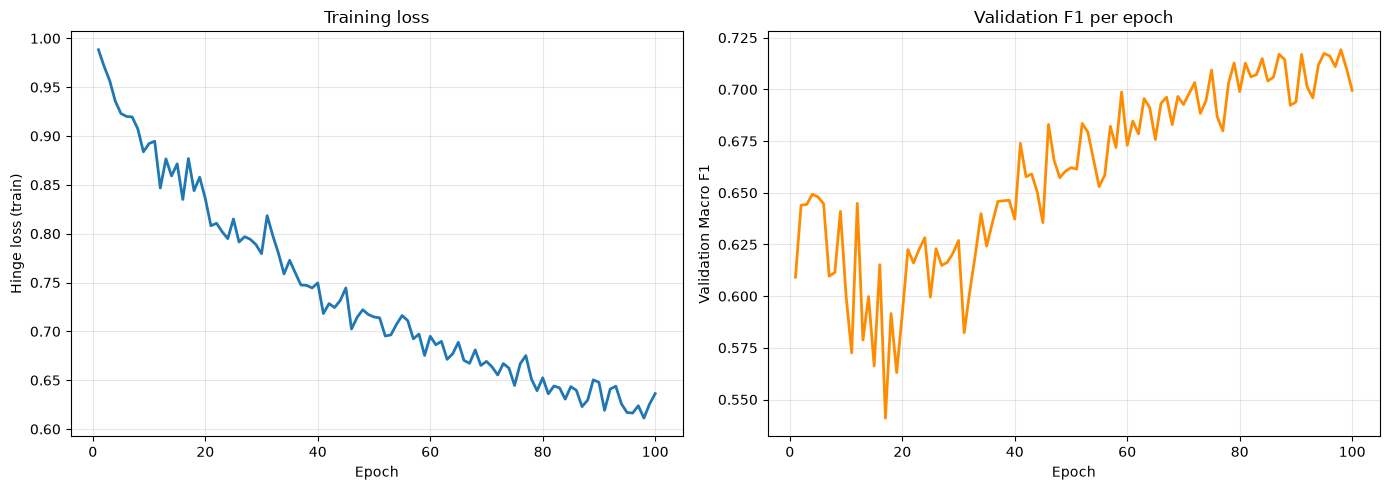

val F1 first 3: [0.6092, 0.644, 0.6443]
val F1 last 3: [0.7192, 0.71, 0.6995]


In [26]:
w_check, b_check, losses_check, val_f1_check = sgd_fit(
    X_train, y_train, loss="hinge", penalty="l2", alpha=1e-4,
    lr=0.5, epochs=100, bs=256, class_weight="balanced",
    X_val=X_val, y_val=y_val, eval_fn=calculate_macro_f1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(losses_check) + 1), losses_check, linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Hinge loss (train)")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(val_f1_check) + 1), val_f1_check, linewidth=2, color="darkorange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Macro F1")
axes[1].set_title("Validation F1 per epoch"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sgd_convergence_check.png", dpi=150)
plt.show()

print("val F1 first 3:", [round(f, 4) for f in val_f1_check[:3]])
print("val F1 last 3:", [round(f, 4) for f in val_f1_check[-3:]])

## 3.4 Extra Trees - permitted library ensemble

Extra Trees is itself an ensemble of randomized decision trees. A decision tree repeatedly splits the feature space into regions. Extra Trees injects additional diversity by considering random feature subsets and randomized split thresholds. Each tree is unstable on its own, but averaging many decorrelated trees reduces variance.

### Hyperparameter meaning

- `n_estimators`: number of trees. More trees usually stabilise the average but increase runtime.
- `max_depth`: maximum tree depth. Smaller values reduce complexity; unrestricted depth can fit detailed interactions.
- `max_features`: number of candidate features considered per split. Lower values increase diversity but may hide useful features.
- `class_weight`: changes the importance of errors from each class.

The controlled sweep changes one parameter at a time from a common baseline. The best retained configuration uses 500 trees, unlimited depth, `max_features="sqrt"`, no class weighting and seed 42.

In [27]:
from sklearn.ensemble import ExtraTreesClassifier   # ensemble model, permitted

t0 = time.time()
extra_trees = ExtraTreesClassifier(n_estimators=500, max_features="sqrt",
                                   random_state=RANDOM_SEED, n_jobs=-1)
extra_trees.fit(X_train, y_train)
et_proba = extra_trees.predict_proba(X_val)[:, 1]

et_default = calculate_macro_f1(y_val, extra_trees.predict(X_val))
et_threshold, et_tuned = best_threshold(y_val, et_proba, calculate_macro_f1)

print(f"train Macro F1     : {calculate_macro_f1(y_train, extra_trees.predict(X_train)):.4f}")
print(f"validation Macro F1: {et_default:.4f}")
print(f"with tuned cut-off : {et_tuned:.4f} (threshold={et_threshold:.3f})  [{time.time()-t0:.0f}s]")

train Macro F1     : 1.0000
validation Macro F1: 0.7189
with tuned cut-off : 0.7598 (threshold=0.574)  [82s]


### Extra Trees result and interpretation

The selected forest reaches training Macro F1 of 1.0000 but only 0.7189 at the default validation threshold. This large gap indicates memorisation. Restricting depth to 20 or 40 reduces training fit but also removes too much useful structure, so it does not improve validation performance. Increasing from 200 to 500 trees gives a small gain; 800 does not improve further, showing diminishing returns once the ensemble average is stable.

Threshold tuning raises validation Macro F1 to approximately 0.7598. Tree-vote proportions are not guaranteed to be calibrated probabilities, so the default 0.5 cut-off is not necessarily the best Macro-F1 operating point. This tuned result should still be interpreted cautiously because the threshold was selected on the same validation set.

## 3.5 Rank-based soft-vote ensemble

An ensemble can improve robustness when its members make different errors. Here, Multinomial NB contributes a generative text view, the SGD classifier contributes a linear discriminative boundary, and Extra Trees contributes nonlinear feature interactions.

Their raw outputs are incompatible: NB produces log-likelihood-like scores, SGD produces signed margins, and Extra Trees produces vote proportions. Each vector is therefore converted to percentile ranks between 0 and 1 before averaging. This preserves ordering while preventing the component with the largest numerical scale from dominating.

In [28]:
def to_rank(scores):
    """Map scores onto [0, 1] by rank, so different scales can be averaged."""
    return np.argsort(np.argsort(scores)) / (len(scores) - 1)


classes, prior, feature_log_prob = nb_fit(X_train, y_train,
                                          alpha=float(nb_grid.iloc[0]["alpha"]))
nb_proba = nb_predict_proba(X_val, prior, feature_log_prob)[:, 1]

w_sgd, b_sgd, _, _ = sgd_fit(X_train, y_train, loss=BEST_SGD_LOSS, penalty="l2",
                             alpha=1e-4, class_weight="balanced", lr=0.5, epochs=100)
sgd_scores = sgd_decision_function(X_val, w_sgd, b_sgd)

vote = np.mean([to_rank(sgd_scores), to_rank(et_proba), to_rank(nb_proba)], axis=0)

# Ranks are uniform on [0, 1], so cutting at 0.5 would force exactly half the
# rows into each class. The class-prior cut-off is the honest default here.
prior_cutoff = 1.0 - y_train.mean()
vote_threshold, vote_tuned = best_threshold(y_val, vote, calculate_macro_f1)

print("cut at 0.5 (forces a 50/50 split):",
      round(calculate_macro_f1(y_val, (vote >= 0.5).astype(int)), 4))
print("cut at the class prior          :",
      round(calculate_macro_f1(y_val, (vote >= prior_cutoff).astype(int)), 4))
print("cut tuned on validation         :", round(vote_tuned, 4),
      f"(threshold={vote_threshold:.3f})")

cut at 0.5 (forces a 50/50 split): 0.7271
cut at the class prior          : 0.7455
cut tuned on validation         : 0.7462 (threshold=0.404)


### Soft-vote result

A 0.5 threshold on percentile ranks forces approximately half the samples into each class, which conflicts with the observed 62.5/37.5 class balance. Using the class prior improves the result, and validation threshold tuning reaches approximately 0.7462 Macro F1.

The ensemble does not beat the tuned Extra Trees result. Diversity helps only when member quality is sufficient: the weaker Naive Bayes component contributes more error than complementary information. This negative result is still useful because it shows that combining more models is not automatically better and motivates weighting stronger models more heavily in later ensemble experiments.

## 3.6 Feature engineering: hybrid TF-IDF and stylometry

The baseline comparison suggests that changing model families on the supplied representation produces limited gains. We therefore keep a transparent linear learner and improve what it can observe.

### Word TF-IDF

Word unigrams and bigrams represent vocabulary and short phrases. Unigrams capture individual lexical choices; bigrams capture local expressions that single words miss.

### Character TF-IDF

Character 3-5 grams inside word boundaries capture spelling fragments, affixes, punctuation-adjacent patterns and formatting texture. Character features are less dependent on exact vocabulary and can remain useful when topics change.

### Stylometry

Stylometry quantifies **how** a document is written rather than only **what** it discusses. The 78 engineered measurements include sentence-length variation, vocabulary richness, word entropy, repeated n-grams and sentence openings, function-word rates, punctuation, formatting and readability. Rates are normalised by suitable document totals so they do not merely reproduce document length.

The input blocks are standardized or normalized and concatenated. The same from-scratch SGD classifier is then used, allowing the before/after comparison to isolate the value of the new representation.

### 3.6.1 TF-IDF implementation from scratch

The vectorizer learns vocabulary and document frequency using training text only, preventing validation leakage. For term $t$ in document $d$ it applies smoothed inverse document frequency

$$\operatorname{idf}(t)=\log\left(\frac{1+N}{1+\operatorname{df}(t)}\right)+1$$

and sublinear term frequency $1+\log(\operatorname{tf})$. Each document is L2-normalised so longer documents do not receive larger scores solely because they contain more tokens. Word and character blocks are normalised independently before concatenation.

In [29]:
from collections import Counter
import math
import re

from scipy import sparse


class ScratchStandardScaler:
    """Column-wise standardization implemented with NumPy."""

    def fit(self, values):
        values = np.asarray(values, dtype=np.float64)
        self.mean_ = values.mean(axis=0)
        self.scale_ = values.std(axis=0)
        self.scale_[self.scale_ == 0.0] = 1.0
        return self

    def transform(self, values):
        values = np.asarray(values, dtype=np.float64)
        return ((values - self.mean_) / self.scale_).astype(np.float32)

    def fit_transform(self, values):
        return self.fit(values).transform(values)


class ScratchTfidfVectorizer:
    """Small TF-IDF vectorizer supporting the settings used by this project."""

    def __init__(self, analyzer, ngram_range, min_df=2, max_df=1.0,
                 max_features=100_000):
        self.analyzer = analyzer
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.max_features = max_features

    @staticmethod
    def _words(text):
        return re.findall(r"(?u)\b\w\w+\b", str(text).lower())

    def _terms(self, text):
        text = "" if pd.isna(text) else str(text)
        low, high = self.ngram_range
        if self.analyzer == "word":
            tokens = self._words(text)
            for n in range(low, high + 1):
                for index in range(len(tokens) - n + 1):
                    yield " ".join(tokens[index:index + n])
            return

        # Like analyzer="char_wb": make character n-grams inside padded words.
        for word in re.findall(r"\S+", text.lower()):
            padded = f" {word} "
            for n in range(low, high + 1):
                for index in range(len(padded) - n + 1):
                    yield padded[index:index + n]

    def fit(self, texts):
        documents = ["" if pd.isna(text) else str(text) for text in texts]
        document_frequency = Counter()
        term_frequency = Counter()
        for text in documents:
            terms = list(self._terms(text))
            term_frequency.update(terms)
            document_frequency.update(set(terms))

        n_documents = len(documents)
        maximum_df = (
            int(self.max_df * n_documents) if isinstance(self.max_df, float)
            else int(self.max_df)
        )
        candidates = [
            term for term, count in document_frequency.items()
            if count >= self.min_df and count <= maximum_df
        ]
        candidates.sort(key=lambda term: (-term_frequency[term], term))
        candidates = candidates[:self.max_features]
        self.vocabulary_ = {term: index for index, term in enumerate(candidates)}
        self.idf_ = np.asarray([
            math.log((1.0 + n_documents) / (1.0 + document_frequency[term])) + 1.0
            for term in candidates
        ], dtype=np.float32)
        return self

    def transform(self, texts):
        texts = list(texts)
        rows, columns, values = [], [], []
        for row, text in enumerate(texts):
            counts = Counter(
                self.vocabulary_[term]
                for term in self._terms(text)
                if term in self.vocabulary_
            )
            if not counts:
                continue
            indices = np.fromiter(counts.keys(), dtype=np.int32)
            data = 1.0 + np.log(np.fromiter(counts.values(), dtype=np.float32))
            data *= self.idf_[indices]
            norm = float(np.linalg.norm(data))
            if norm:
                data /= norm
            rows.extend([row] * len(indices))
            columns.extend(indices.tolist())
            values.extend(data.tolist())
        return sparse.csr_matrix(
            (values, (rows, columns)),
            shape=(len(texts), len(self.vocabulary_)),
            dtype=np.float32,
        )

    def fit_transform(self, texts):
        texts = list(texts)
        return self.fit(texts).transform(texts)


class ScratchHybridTfidf:
    """Union of independently normalized word and character TF-IDF."""

    def __init__(self, min_df=5):
        # min_df=5 drops terms seen in fewer than five documents. Those are
        # mostly topic-specific one-offs that do not survive a change of domain,
        # and cutting them costs nothing on validation.
        self.word = ScratchTfidfVectorizer("word", (1, 2), min_df, 0.98, 100_000)
        self.character = ScratchTfidfVectorizer("char_wb", (3, 5), min_df, 1.0, 100_000)

    def fit_transform(self, texts):
        texts = list(texts)
        return sparse.hstack(
            [self.word.fit_transform(texts), self.character.fit_transform(texts)],
            format="csr",
        )

    def transform(self, texts):
        texts = list(texts)
        return sparse.hstack(
            [self.word.transform(texts), self.character.transform(texts)],
            format="csr",
        )

### 3.6.2 Stylometric implementation

The stylometric block turns qualitative writing habits into numerical variables. Examples include:

- **Burstiness:** standard deviation and range of sentence lengths;
- **Lexical diversity:** unique-word ratio, hapax ratio and entropy;
- **Repetition:** repeated word n-grams and repeated sentence openings;
- **Function words:** pronoun, article, preposition, conjunction and transition rates;
- **Surface form:** punctuation, capitalization, digits, whitespace and line structure;
- **Readability:** approximations based on word, sentence and syllable counts.

These are standardized using training-set means and standard deviations. Standardization is important because a count measured in hundreds should not dominate a ratio between zero and one merely due to scale.

In [30]:
FUNCTION_WORD_GROUPS = {
    "first_person": {"i", "me", "my", "mine", "we", "us", "our", "ours"},
    "second_person": {"you", "your", "yours"},
    "third_person": {"he", "she", "it", "they", "him", "her", "them", "their"},
    "articles": {"a", "an", "the"},
    "conjunctions": {"and", "but", "or", "although", "because", "while", "whereas"},
    "prepositions": {"of", "to", "in", "for", "with", "on", "at", "from", "by"},
    "demonstratives": {"this", "that", "these", "those"},
    "modals": {"can", "could", "may", "might", "must", "shall", "should", "will", "would"},
    "negations": {"no", "not", "never", "neither", "nor", "none", "without"},
    "transitions": {
        "however", "therefore", "moreover", "furthermore", "additionally",
        "consequently", "nevertheless", "overall", "thus", "hence",
    },
}


def safe_stats(values):
    if not values:
        return [0.0] * 7
    array = np.asarray(values, dtype=np.float64)
    mean = float(array.mean())
    std = float(array.std())
    return [
        mean,
        std,
        float(array.min()),
        float(array.max()),
        float(np.median(array)),
        std / (mean + 1e-8),
        float(np.quantile(array, 0.75) - np.quantile(array, 0.25)),
    ]


def approximate_syllables(word):
    groups = re.findall(r"[aeiouy]+", word.lower())
    count = len(groups)
    if word.lower().endswith("e") and count > 1:
        count -= 1
    return max(count, 1)


def repetition_ratio(items, n):
    grams = list(zip(*(items[index:] for index in range(n))))
    if not grams:
        return 0.0
    return 1.0 - len(set(grams)) / len(grams)


def advanced_style_features(text):
    text = "" if pd.isna(text) else str(text)
    lower = text.lower()
    words = re.findall(r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b", lower)
    sentences = [part.strip() for part in re.split(r"[.!?]+", text) if part.strip()]
    paragraphs = [part.strip() for part in re.split(r"\n\s*\n", text) if part.strip()]
    word_count = max(len(words), 1)
    char_count = max(len(text), 1)
    sentence_count = max(len(sentences), 1)
    counts = Counter(words)
    unique_count = len(counts)

    sentence_lengths = [len(re.findall(r"\b\w+\b", sentence)) for sentence in sentences]
    word_lengths = [len(word) for word in words]
    paragraph_lengths = [len(re.findall(r"\b\w+\b", paragraph)) for paragraph in paragraphs]

    frequency_values = np.asarray(list(counts.values()), dtype=np.float64)
    probabilities = frequency_values / frequency_values.sum() if frequency_values.size else np.array([])
    entropy = float(-(probabilities * np.log2(probabilities)).sum()) if probabilities.size else 0.0
    hapax = sum(value == 1 for value in counts.values()) / word_count
    dis_legomena = sum(value == 2 for value in counts.values()) / word_count
    repeated_words = (len(words) - unique_count) / word_count
    most_common_rate = max(counts.values(), default=0) / word_count

    sentence_openings = [
        tuple(re.findall(r"\b[a-zA-Z]+\b", sentence.lower())[:2])
        for sentence in sentences
    ]
    opening_repetition = (
        1.0 - len(set(sentence_openings)) / len(sentence_openings)
        if sentence_openings else 0.0
    )

    syllables = sum(approximate_syllables(word) for word in words)
    syllables_per_word = syllables / word_count
    words_per_sentence = len(words) / sentence_count
    flesch = 206.835 - 1.015 * words_per_sentence - 84.6 * syllables_per_word
    flesch_kincaid = 0.39 * words_per_sentence + 11.8 * syllables_per_word - 15.59
    complex_ratio = sum(approximate_syllables(word) >= 3 for word in words) / word_count
    gunning_fog = 0.4 * (words_per_sentence + 100 * complex_ratio)

    features = [
        len(text), len(words), len(sentences), len(paragraphs),
        unique_count / word_count,
        unique_count / math.sqrt(word_count),
        unique_count / math.sqrt(2 * word_count),
        hapax, dis_legomena, repeated_words, most_common_rate, entropy,
        repetition_ratio(words, 2), repetition_ratio(words, 3), opening_repetition,
    ]
    features.extend(safe_stats(sentence_lengths))
    features.extend([
        sum(length <= 8 for length in sentence_lengths) / sentence_count,
        sum(length >= 30 for length in sentence_lengths) / sentence_count,
    ])
    features.extend(safe_stats(word_lengths))
    features.extend([
        sum(length <= 3 for length in word_lengths) / word_count,
        sum(4 <= length <= 6 for length in word_lengths) / word_count,
        sum(7 <= length <= 9 for length in word_lengths) / word_count,
        sum(length >= 10 for length in word_lengths) / word_count,
    ])
    features.extend(safe_stats(paragraph_lengths))

    for group in FUNCTION_WORD_GROUPS.values():
        features.append(sum(counts[word] for word in group) / word_count)

    features.extend([
        sum(character.isupper() for character in text) / char_count,
        sum(character.isdigit() for character in text) / char_count,
        sum(character.isspace() for character in text) / char_count,
        *(text.count(mark) / char_count for mark in [",", ";", ":", "?", "!", "-", "(", ")", '"', "'"]),
        text.count("\n") / char_count,
        len(re.findall(r"(?m)^\s*[-*•]\s+", text)) / sentence_count,
        len(re.findall(r"[!?.,]{2,}", text)) / sentence_count,
        len(re.findall(r"\([A-Z][A-Za-z-]+,?\s+\d{4}[a-z]?\)", text)) / sentence_count,
        len(re.findall(r"\[\d+(?:\s*,\s*\d+)*\]", text)) / sentence_count,
        len(re.findall(r"\b\d+(?:\.\d+)?%", text)) / word_count,
        len(re.findall(r"\b[A-Z]{2,}\b", text)) / word_count,
        len(re.findall(r"\([^)]{3,}\)", text)) / sentence_count,
        syllables_per_word, flesch, flesch_kincaid, complex_ratio, gunning_fog,
    ])
    return np.nan_to_num(np.asarray(features, dtype=np.float32))


def style_matrix(texts):
    return np.vstack([advanced_style_features(text) for text in texts])


def combine(tfidf, styles, weight):
    """Glue the stylometry block onto the TF-IDF block.

    `weight` sets how loud the 78 stylometry columns are next to the 200k
    TF-IDF columns; without it they would be drowned out.
    """
    return sparse.hstack(
        [tfidf, sparse.csr_matrix(styles * weight)], format="csr"
    )

### 3.6.3 Controlled feature comparison

The learner remains the same `sgd_fit` implementation used in Section 3.3. Only the representation changes. This controlled design supports a stronger conclusion: any large improvement is attributable primarily to the word, character and stylometric information rather than a different optimizer.

In [31]:
train_text = train_raw.loc[is_train, "text"]
val_text = train_raw.loc[~is_train, "text"]
y_train_text = train_raw.loc[is_train, LABEL_COLUMN].to_numpy()
y_val_text = train_raw.loc[~is_train, LABEL_COLUMN].to_numpy()

t0 = time.time()
vectorizer = ScratchHybridTfidf()
train_tfidf = vectorizer.fit_transform(train_text)
val_tfidf = vectorizer.transform(val_text)

scaler = ScratchStandardScaler()
train_styles = scaler.fit_transform(style_matrix(train_text))
val_styles = scaler.transform(style_matrix(val_text))

print(f"TF-IDF block: {train_tfidf.shape}, stylometry block: {train_styles.shape}"
      f"  [{time.time()-t0:.0f}s]")

TF-IDF block: (16000, 200000), stylometry block: (16000, 78)  [38s]


## 3.7 Re-testing the loss after changing features

A hyperparameter is not universally optimal; it interacts with the feature representation. Modified Huber was strongest on the supplied TF-IDF matrix, but the hybrid representation changes scale, sparsity and separability. We therefore compare hinge, modified Huber and log loss again under identical hybrid features.

Modified Huber reaches 0.8513, compared with 0.8278 for hinge and 0.8063 for log loss. Re-testing the earlier choice recovers about 0.02 Macro F1 relative to hinge. This was an important practical lesson: reuse the experimental method, not an unverified setting.

In [32]:
x_train_hybrid = combine(train_tfidf, train_styles, 0.10)
x_val_hybrid = combine(val_tfidf, val_styles, 0.10)

loss_rows = []
for loss_name in ["hinge", "modified_huber", "log_loss"]:
    t0 = time.time()
    w_h, b_h, _, _ = sgd_fit(x_train_hybrid, y_train_text, loss=loss_name,
                             penalty="l2", alpha=1e-5, class_weight="balanced",
                             lr=0.5, epochs=60, bs=256, random_state=RANDOM_SEED)
    score = calculate_macro_f1(y_val_text, sgd_predict(x_val_hybrid, w_h, b_h))
    loss_rows.append({"loss": loss_name, "val_macro_f1": score,
                      "fit_seconds": round(time.time() - t0, 1)})
    print(f"loss={loss_name:<16} F1={score:.4f}")

pd.DataFrame(loss_rows).to_csv(RESULTS_DIR / "task3_loss_on_hybrid.csv", index=False)
pd.DataFrame(loss_rows)

loss=hinge            F1=0.8278
loss=modified_huber   F1=0.8513
loss=log_loss         F1=0.8063


,loss,val_macro_f1,fit_seconds
0,hinge,0.827785,5.5
1,modified_huber,0.851330,5.5
2,log_loss,0.806323,5.5


## 3.8 Stylometry-weight tuning

`style_weight` controls the contribution of the compact 78-column style block relative to approximately 200,000 sparse TF-IDF columns. If the weight is too small, style information has little effect; if it is too large, a small set of handcrafted measurements can overwhelm lexical evidence.

The tested values are 0.05, 0.10, 0.25 and 0.50. On the random split, 0.10 is best at 0.8513. Performance declines at 0.50, supporting the view that stylometry should complement rather than replace TF-IDF.

In [33]:
style_rows = []
for weight in [0.05, 0.10, 0.25, 0.50]:
    x_tr = combine(train_tfidf, train_styles, weight)
    x_va = combine(val_tfidf, val_styles, weight)

    t0 = time.time()
    w_s, b_s, _, _ = sgd_fit(x_tr, y_train_text, loss="modified_huber",
                             penalty="l2", alpha=1e-5, class_weight="balanced",
                             lr=0.5, epochs=60, bs=256, random_state=RANDOM_SEED)
    scores = sgd_decision_function(x_va, w_s, b_s)
    style_rows.append({
        "style_weight": weight,
        "val_macro_f1": calculate_macro_f1(y_val_text, (scores >= 0).astype(int)),
        "fit_seconds": round(time.time() - t0, 1),
    })
    print(f"style_weight={weight:<5} F1={style_rows[-1]['val_macro_f1']:.4f}")

style_results = (pd.DataFrame(style_rows)
                 .sort_values("val_macro_f1", ascending=False)
                 .reset_index(drop=True))
style_results.to_csv(RESULTS_DIR / "task3_final_model_results.csv", index=False)
style_results

style_weight=0.05  F1=0.8428
style_weight=0.1   F1=0.8513
style_weight=0.25  F1=0.8471
style_weight=0.5   F1=0.8410


,style_weight,val_macro_f1,fit_seconds
0,0.10,0.851330,5.5
1,0.25,0.847100,5.5
2,0.05,0.842836,5.5
3,0.50,0.841033,5.5


### What produced the improvement?

Using the same from-scratch linear trainer, the validation score increases from 0.7446 with supplied features to 0.8513 with the hybrid representation. This is the largest improvement in the project. The result shows that the earlier bottleneck was feature representation: models could not learn patterns that were absent from their inputs.

The gap among style weights 0.05-0.25 is small on the random split, so the next section tests whether the choice remains stable when the validation distribution is made deliberately harder.

## 3.9 Distribution shift: why random validation is optimistic

The hybrid model reaches about 0.85 on the shared random split but approximately 0.799 on the recorded Kaggle leaderboard submission. A plausible explanation is **distribution shift**: random splitting places related topics and writing sources on both sides, while the hidden test set may contain different mixtures. This is an inference from the score gap and cluster experiment, not knowledge of hidden labels.

To test robustness without accessing test labels, PCA reduces the supplied features to 100 dimensions and KMeans creates five topic-like clusters. One entire cluster is held out at a time. The classifier must then generalise to a group not represented in its training fold. KMeans is used only to construct this diagnostic split, never to predict the class.

In [34]:
from sklearn.cluster import KMeans

# k-means on the raw 5000-dimensional L2-normalised rows collapses almost
# everything into a single cluster, so we reduce to 100 components first
reduced = PCA(n_components=100, random_state=RANDOM_SEED).fit_transform(X_all)
clusters = KMeans(n_clusters=5, random_state=RANDOM_SEED, n_init=10).fit_predict(reduced)

print("cluster sizes:", np.bincount(clusters))
print("class-1 rate per cluster:",
      [round(float(y_all[clusters == g].mean()), 3) for g in range(5)])

cluster sizes: [4512 1956 1075 3840 8617]
class-1 rate per cluster: [0.545, 0.664, 0.7, 0.624, 0.65]


In [35]:
shift_rows = []
for held_out in range(5):
    tr, va = clusters != held_out, clusters == held_out
    t0 = time.time()

    fold_vec = ScratchHybridTfidf()
    tfidf_tr = fold_vec.fit_transform(train_raw.loc[tr, "text"])
    tfidf_va = fold_vec.transform(train_raw.loc[va, "text"])
    fold_scaler = ScratchStandardScaler()
    styles_tr = fold_scaler.fit_transform(style_matrix(train_raw.loc[tr, "text"]))
    styles_va = fold_scaler.transform(style_matrix(train_raw.loc[va, "text"]))

    for weight in [0.10, 0.25]:
        w_f, b_f, _, _ = sgd_fit(combine(tfidf_tr, styles_tr, weight), y_all[tr],
                                 loss="modified_huber", penalty="l2", alpha=1e-5,
                                 class_weight="balanced", lr=0.5, epochs=60,
                                 bs=256, random_state=RANDOM_SEED)
        scores = sgd_decision_function(combine(tfidf_va, styles_va, weight), w_f, b_f)
        shift_rows.append({
            "held_out_cluster": held_out, "n_val": int(va.sum()),
            "style_weight": weight,
            "macro_f1": calculate_macro_f1(y_all[va], (scores >= 0).astype(int)),
        })
    print(f"cluster {held_out} (n={va.sum():>5}) "
          + "  ".join(f"sw{r['style_weight']}={r['macro_f1']:.4f}"
                      for r in shift_rows[-2:]) + f"  [{time.time()-t0:.0f}s]")

shift_results = pd.DataFrame(shift_rows)
shift_results.to_csv(RESULTS_DIR / "task3_shift_validation.csv", index=False)
display(shift_results.groupby("style_weight")["macro_f1"].mean().round(4).to_frame("mean_macro_f1"))

cluster 0 (n= 4512) sw0.1=0.7509  sw0.25=0.7544  [47s]
cluster 1 (n= 1956) sw0.1=0.7889  sw0.25=0.8036  [50s]
cluster 2 (n= 1075) sw0.1=0.8564  sw0.25=0.8512  [51s]
cluster 3 (n= 3840) sw0.1=0.7969  sw0.25=0.7969  [47s]
cluster 4 (n= 8617) sw0.1=0.7725  sw0.25=0.7732  [44s]


,mean_macro_f1
style_weight,
0.10,0.7931
0.25,0.7958


### Distribution-shift findings

The mean cluster-holdout Macro F1 is about 0.79-0.80, much closer to the recorded Kaggle score than the random-split result. Performance also varies considerably across clusters, showing that model quality depends on the held-out domain. This supports three conclusions:

1. The 0.85 random-split score is useful for controlled comparisons but optimistic for unseen distributions.
2. Small improvements on one validation split should not be over-interpreted.
3. Stylometry is somewhat more transferable than topic vocabulary: weight 0.25 is marginally stronger under cluster holdout even though 0.10 wins on the random split.

For the final fit, weight 0.25 is selected as the more shift-aware setting. If repeating the project, grouped or source-aware validation would be designed before tuning rather than added after observing a leaderboard gap.

## 3.10 Final Task 3 model

The selected model uses independently normalized word and character TF-IDF, standardized stylometry with weight 0.25, modified Huber loss, balanced class weights, L2 regularisation and averaged SGD. The settings are fixed before refitting on all 20,000 labelled rows. The final class-1 prediction rate is checked against the training distribution as a sanity check, not forced to match a predetermined quota.

In [36]:
# Fixed from Section 3.7 rather than re-selected on the random split, which
# cannot see the shift the leaderboard puts us under.
BEST_STYLE_WEIGHT = 0.25
BEST_EPOCHS = 60

t0 = time.time()
final_vectorizer = ScratchHybridTfidf()
all_tfidf = final_vectorizer.fit_transform(train_raw["text"])
test_tfidf = final_vectorizer.transform(test_raw["text"])

final_scaler = ScratchStandardScaler()
all_styles = final_scaler.fit_transform(style_matrix(train_raw["text"]))
test_styles = final_scaler.transform(style_matrix(test_raw["text"]))

x_all = combine(all_tfidf, all_styles, BEST_STYLE_WEIGHT)
x_test = combine(test_tfidf, test_styles, BEST_STYLE_WEIGHT)

final_w, final_b, _, _ = sgd_fit(x_all, train_raw[LABEL_COLUMN].to_numpy(),
                                 loss="modified_huber", penalty="l2", alpha=1e-5,
                                 class_weight="balanced", lr=0.5, epochs=BEST_EPOCHS,
                                 bs=256, random_state=RANDOM_SEED)

# Threshold left at 0: tuning it on 4000 validation rows gains under 0.002,
# which is inside the noise of that split.
final_preds = sgd_predict(x_test, final_w, final_b, threshold=0.0)

create_submission(
    test_ids=test_raw[ID_COLUMN],
    predictions=final_preds,
    output_path=SUBMISSIONS_DIR / "Final_Prediction.csv",
    id_column=ID_COLUMN,
    label_column=LABEL_COLUMN,
)
print(f"Final_Prediction.csv saved; class-1 rate={final_preds.mean():.4f}"
      f" (training rate {train_raw[LABEL_COLUMN].mean():.4f})  [{time.time()-t0:.0f}s]")

Final_Prediction.csv saved; class-1 rate=0.6234 (training rate 0.6252)  [59s]


In [37]:
# Format check on the final submission
saved = pd.read_csv(SUBMISSIONS_DIR / "Final_Prediction.csv", dtype={ID_COLUMN: "string"})
assert saved.columns.tolist() == [ID_COLUMN, LABEL_COLUMN]
assert len(saved) == len(test_raw)
assert saved[ID_COLUMN].tolist() == test_raw[ID_COLUMN].astype("string").tolist()
assert saved[LABEL_COLUMN].isnull().sum() == 0
assert set(saved[LABEL_COLUMN].unique()).issubset({0, 1})
print("Final_Prediction.csv verified  ready to upload")

Final_Prediction.csv verified  ready to upload


---
# 4. Consolidated results

The table below reports local Macro F1 on the same 4,000-row shared validation set. A “tuned” value means that the decision threshold was selected using those validation labels, so it is useful for model development but may be optimistic. Formal Task 1 and Task 2 reporting should use their Kaggle public scores; Task 3 should discuss both local validation and leaderboard transfer.

In [38]:
summary = pd.DataFrame([
    {"task": 1, "model": "Logistic Regression", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(logreg_results.iloc[0]["val_macro_f1"]),
     "val_macro_f1_tuned": float(logreg_results.iloc[0]["val_macro_f1_tuned"])},
    {"task": 2, "model": "PCA(100) + KNN k=2", "features": "provided 5000 TF-IDF",
     "implementation": "sklearn (permitted)",
     "val_macro_f1": float(pca_results.set_index("components").loc[100, "val_macro_f1"]),
     "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Multinomial Naive Bayes", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(nb_grid.iloc[0]["val_macro_f1"]), "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Complement Naive Bayes", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(cnb_grid.iloc[0]["val_macro_f1"]), "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Linear classifier by SGD", "features": "provided 5000 TF-IDF",
     "implementation": "from scratch",
     "val_macro_f1": float(sgd_grid["val_macro_f1"].max()), "val_macro_f1_tuned": np.nan},
    {"task": 3, "model": "Extra Trees", "features": "provided 5000 TF-IDF",
     "implementation": "sklearn ensemble (permitted)",
     "val_macro_f1": et_default, "val_macro_f1_tuned": et_tuned},
    {"task": 3, "model": "Soft vote (linear + Extra Trees + NB)", "features": "provided 5000 TF-IDF",
     "implementation": "ensemble",
     "val_macro_f1": calculate_macro_f1(y_val, (vote >= 0.5).astype(int)),
     "val_macro_f1_tuned": vote_tuned},
    {"task": 3, "model": "Hybrid TF-IDF + stylometry + SGD (modified Huber)",
     "features": "our own", "implementation": "from scratch",
     "val_macro_f1": float(style_results["val_macro_f1"].max()),
     "val_macro_f1_tuned": np.nan},
])

summary = summary.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
summary.to_csv(RESULTS_DIR / "final_summary.csv", index=False)

print("Random-split validation, for ranking models against each other.")
print("Section 3.7 shows why the top row does not transfer to the leaderboard "
      "one for one.")
summary.round(4)

Random-split validation, for ranking models against each other.
Section 3.7 shows why the top row does not transfer to the leaderboard one for one.


,task,model,features,implementation,val_macro_f1,val_macro_f1_tuned
0,3,Hybrid TF-IDF + stylometry + SGD (modified Huber),our own,from scratch,0.8513,NaN
1,3,Linear classifier by SGD,provided 5000 TF-IDF,from scratch,0.7446,NaN
2,3,Soft vote (linear + Extra Trees + NB),provided 5000 TF-IDF,ensemble,0.7271,0.7462
3,1,Logistic Regression,provided 5000 TF-IDF,from scratch,0.7227,0.7440
4,3,Extra Trees,provided 5000 TF-IDF,sklearn ensemble (permitted),0.7189,0.7598
5,3,Multinomial Naive Bayes,provided 5000 TF-IDF,from scratch,0.6741,NaN
6,3,Complement Naive Bayes,provided 5000 TF-IDF,from scratch,0.6669,NaN
7,2,PCA(100) + KNN k=2,provided 5000 TF-IDF,sklearn (permitted),0.6556,NaN


## 4.1 Score reporting convention

| Task / submission | Local validation Macro F1 | Recorded Kaggle public Macro F1 | Interpretation |
|---|---:|---:|---|
| Task 1 Logistic Regression | up to 0.7440 tuned | **0.68563** | Formal Task 1 score is the Kaggle value |
| Task 2 PCA(100) + KNN | 0.6556 | **0.67793** | Best recorded PCA/KNN submission |
| Task 3 hybrid TF-IDF + stylometry SGD | 0.8513 random split; about 0.796 cluster holdout | **0.78011** | Cluster holdout is more representative than random splitting |

Local validation supports controlled experimentation; Kaggle public F1 measures transfer to part of the hidden test set. The public leaderboard itself is also an estimate rather than the final private score, so model choices should not be based on repeated leaderboard probing.

# 5. Discussion, conclusion and reflection

## 5.1 Main findings

1. **Representation produced the largest gain.** Changing the supplied 5,000 features to word TF-IDF, character TF-IDF and stylometry raised the same SGD family from 0.7446 to 0.8513 local Macro F1.
2. **Dimensionality can harm a distance model.** PCA(100) outperformed PCA(2000) because KNN distances became more meaningful after aggressive compression and because `k=2` ties biased predictions toward class 0.
3. **Hyperparameters depend on the feature space.** Modified Huber had to be re-tested after feature engineering; assuming hinge loss remained suitable would have lost roughly 0.02 Macro F1.
4. **More ensemble members do not guarantee improvement.** The soft vote was limited by its weaker Naive Bayes component, whereas tuned Extra Trees alone performed better.
5. **Validation design matters.** Cluster holdout explained why 0.85 random-split performance transferred to roughly 0.80 on Kaggle.

## 5.2 Difficulties and actions taken

| Difficulty | Evidence | Action taken | Outcome |
|---|---|---|---|
| Class imbalance made default thresholds misleading | Majority baseline had Macro F1 0.3847 | Used Macro F1, tested balanced weights and tuned thresholds only on validation | Better balance between class-specific precision and recall |
| KNN became unreliable in high dimensions | PCA(2000) scored 0.4007 and produced many ties | Compared four component counts and measured tie behaviour | Identified PCA(100) as the strongest required setting |
| Sparse text features made scratch training memory-sensitive | Hybrid feature space had about 200,000 columns | Used sparse matrices, capped vocabularies and float32 storage | Preserved feasible training without dense conversion |
| Strong training performance did not transfer fully to Kaggle | Random validation about 0.85 versus leaderboard about 0.799 | Built topic-cluster holdout validation | Produced a more realistic estimate near 0.80 |
| Some ensemble members reduced performance | Soft vote remained below tuned Extra Trees | Compared individual and combined results instead of assuming diversity was sufficient | Retained the negative result and learned when weighting is necessary |

## 5.3 Limitations and practical improvements

- The shared validation set is a random sample and may contain the same topics or sources as training. Future work should use source-aware or grouped cross-validation when metadata permit it.
- Threshold tuning on one validation set can overfit 4,000 labels. Nested cross-validation or out-of-fold predictions would give a less biased operating threshold.
- Stylometric rules may be sensitive to language, genre and deliberate editing. Error analysis by document source and length would show where the features fail.
- Character and word vocabularies are capped for memory. Feature hashing or more efficient sparse storage could test larger spaces without changing the classical-learning constraint.
- The project deliberately excludes deep learning. Practical improvements should therefore focus on better validation, calibrated weighted ensembles, error analysis and robust classical features rather than prohibited pretrained models.

## 5.4 What we learned beyond the course

The project required us to learn how TF-IDF can be implemented directly, how sparse dot products make high-dimensional text learning practical, and how stylometry converts writing behaviour into measurable features. We also learned that decision scores from different models cannot be averaged safely until their scales are made comparable, motivating rank-based blending. Most importantly, we learned to distinguish optimisation success from generalisation: decreasing training loss and high random-split F1 do not guarantee transfer under domain shift.

## 5.5 Conclusion

The strongest approach is not the most complicated algorithm. A transparent linear learner became competitive after it received a representation designed for the task. Word n-grams capture lexical content, character n-grams capture surface patterns, and stylometry captures structural regularity. Modified Huber loss and modest style weighting then provide a stable boundary. The remaining leaderboard gap is best explained by distribution shift, so the most valuable next improvement is a more representative validation design rather than increasingly aggressive tuning on the same split.

## 5.6 Member contribution

| Team member | Contribution |
|---|---|
| **Akshitha Shree Gokulraj** | Data loading and inspection; dataset summary statistics; creation of the shared stratified train/validation split; reusable Macro F1 evaluation and submission-writing utilities; Linear SVM tuning using different `C` and class-weight settings; prediction generation; report formatting; and final submission-file verification. |
| **Suheera Banu** | Complete Task 1 implementation: Logistic Regression from scratch, including sigmoid, log loss, gradients, mini-batch training and prediction; learning-rate, epoch, batch-size, L2 regularisation and threshold tuning; training-loss visualisation; generation of `LogReg_Prediction.csv`; and verification of mathematical formulas and technical explanations. |
| **Tina Singh** | Complete Task 2 implementation: PCA using 2,000, 1,000, 500 and 100 components without validation leakage; KNN with `n_neighbors=2`; explained-variance, runtime and dimensionality analysis; investigation of prediction ties; generation of four PCA/KNN submission files; preparation of the PCA results figure; and verification of report tables, graphs and scores. |
| **Janani Suraparaj** | Task 3 from-scratch models: implementation of the SGD linear classifier with hinge, modified Huber and log loss; class balancing and weight averaging; Multinomial and Complement Naive Bayes; loss, alpha, penalty and class-weight experiments; convergence analysis; maintenance of the experiment log; and verification of hyperparameters and code comments. |
| **Lavanya Gupta** | Task 3 ensembles and feature engineering: Extra Trees tuning; Ensemble 1 and Ensemble 2 with model-weight experiments; XGBoost exploration; implementation of the hybrid word/character TF-IDF vectoriser from scratch; development of 78 stylometric features; stylometry-booster ensemble; rank and group-rank calibration |